Dataset Loaded Successfully
    job_id                 job_title  salary_usd salary_currency  \
0  AI00001            Data Scientist      219728             USD   
1  AI00002                Head of AI      230237             JPY   
2  AI00003             Data Engineer      128890             EUR   
3  AI00004  Computer Vision Engineer       96349             USD   
4  AI00005         Robotics Engineer       63065             EUR   

   salary_local experience_level employment_type company_location  \
0        219728               EX              PT           Sweden   
1      25326070               EX              PT            Japan   
2        109557               EX              CT          Germany   
3         96349               MI              FL          Finland   
4         53605               EN              FT           France   

  company_size employee_residence  remote_ratio  \
0            M             Sweden             0   
1            L              Japan            5

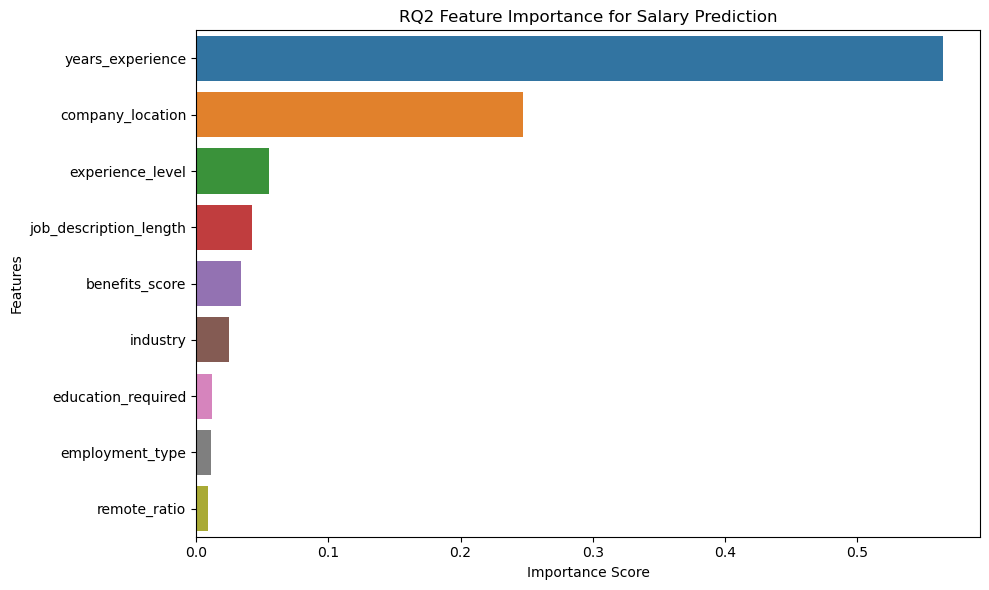

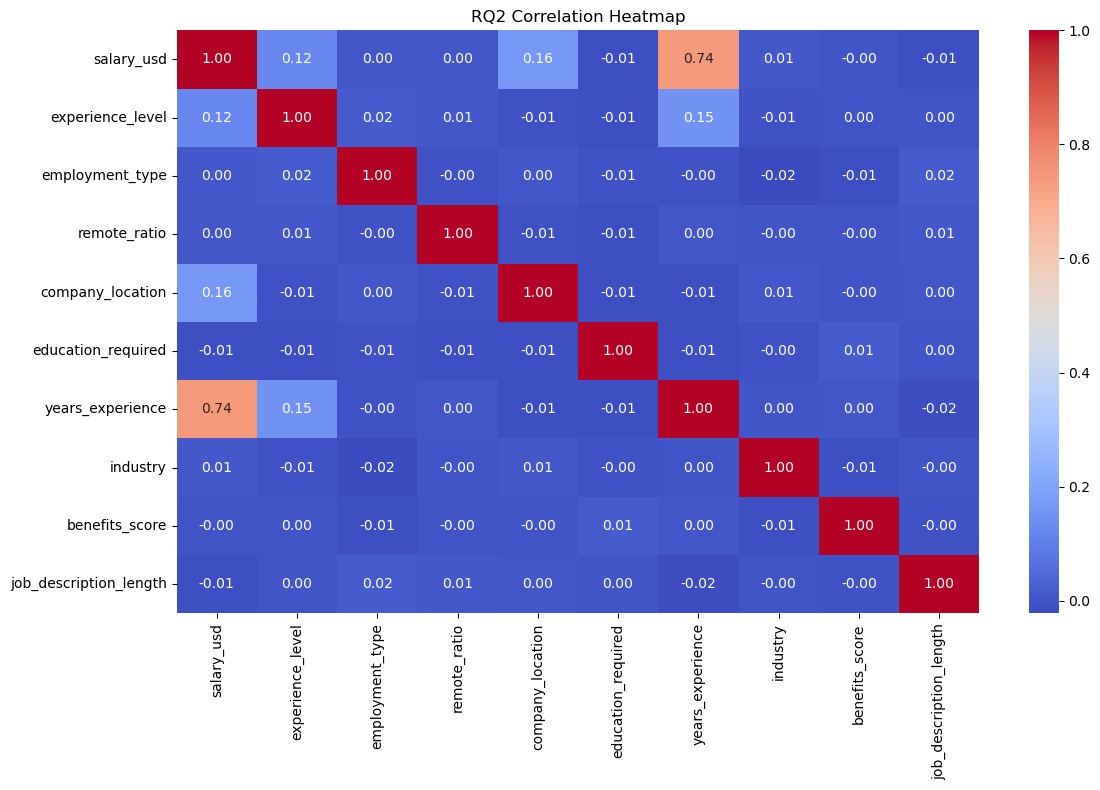

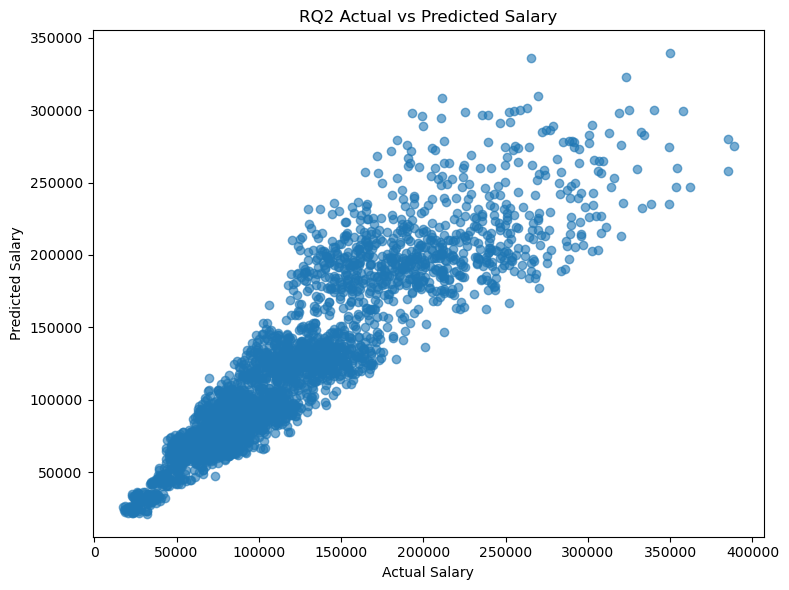

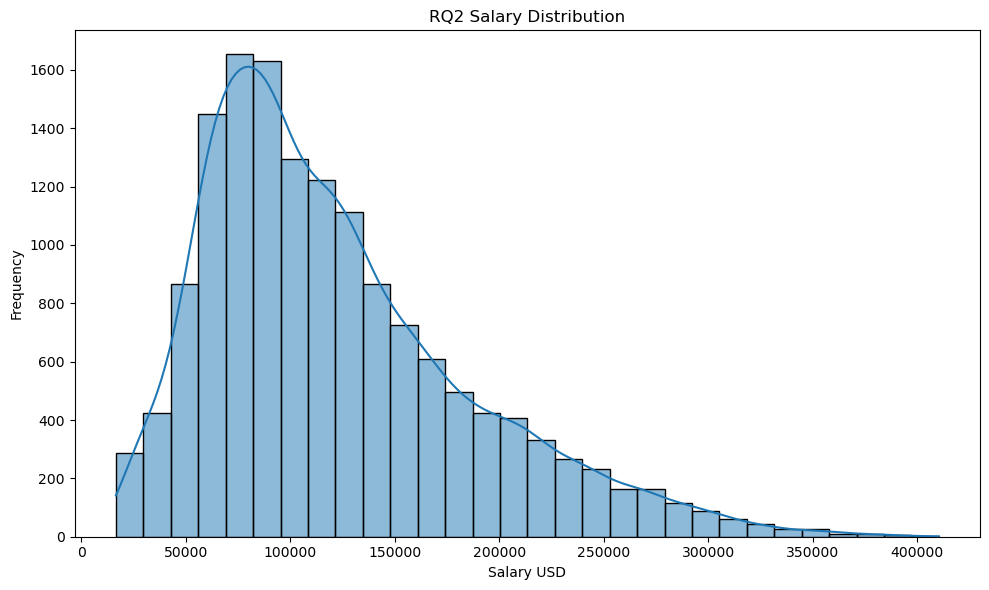


Predictions Table Saved

FINAL CONCLUSION
The most influential feature affecting salary prediction is: years_experience
Random Forest Regression successfully identified the most important job-related factors influencing salary prediction.

All figures saved in 'models' folder
All tables saved in 'tables' folder


In [1]:


# RQ2.Which job-related features have the strongest influence on salary prediction?




import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


os.makedirs("models", exist_ok=True)
os.makedirs("tables", exist_ok=True)


df = pd.read_csv("ai_job_dataset1.csv")

print("Dataset Loaded Successfully")
print(df.head())



selected_columns = [
    'salary_usd',
    'experience_level',
    'employment_type',
    'remote_ratio',
    'company_location',
    'education_required',
    'years_experience',
    'industry',
    'benefits_score',
    'job_description_length'
]

data = df[selected_columns]

data = data.dropna()


label_encoders = {}

categorical_columns = [
    'experience_level',
    'employment_type',
    'company_location',
    'education_required',
    'industry'
]

for column in categorical_columns:

    le = LabelEncoder()

    data[column] = le.fit_transform(data[column])

    label_encoders[column] = le

print("\nCategorical Variables Encoded Successfully")


X = data.drop('salary_usd', axis=1)

y = data['salary_usd']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")



y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


performance_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})

performance_table.to_csv(
    'tables/RQ2_model_performance.csv',
    index=False
)

print("\nPerformance Table Saved")


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(feature_importance)

feature_importance.to_csv(
    'tables/RQ2_feature_importance.csv',
    index=False
)

print("\nFeature Importance Table Saved")

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title(
    'RQ2 Feature Importance for Salary Prediction'
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.tight_layout()

plt.savefig(
    'models/RQ2_feature_importance_bar_chart.png'
)

plt.show()

plt.figure(figsize=(12,8))

correlation_matrix = data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'RQ2 Correlation Heatmap'
)

plt.tight_layout()

plt.savefig(
    'models/RQ2_correlation_heatmap.png'
)

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel('Actual Salary')

plt.ylabel('Predicted Salary')

plt.title(
    'RQ2 Actual vs Predicted Salary'
)

plt.tight_layout()

plt.savefig(
    'models/RQ2_actual_vs_predicted.png'
)

plt.show()

plt.figure(figsize=(10,6))

sns.histplot(
    data['salary_usd'],
    bins=30,
    kde=True
)

plt.title(
    'RQ2 Salary Distribution'
)

plt.xlabel('Salary USD')

plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig(
    'models/RQ2_salary_distribution.png'
)

plt.show()

predictions_table = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

predictions_table.to_csv(
    'tables/RQ2_predictions.csv',
    index=False
)

print("\nPredictions Table Saved")

top_feature = feature_importance.iloc[0]['Feature']

print("\n======================================")
print("FINAL CONCLUSION")
print("======================================")

print(
    f"The most influential feature affecting salary "
    f"prediction is: {top_feature}"
)

print(
    "Random Forest Regression successfully identified "
    "the most important job-related factors influencing "
    "salary prediction."
)

print("\nAll figures saved in 'models' folder")
print("All tables saved in 'tables' folder")